PyTorch not found. Installing PyTorch...
PyTorch is ready!
Dataset created successfully!
Total samples: 40

Class distribution:
sentiment
1    20
0    20
Name: count, dtype: int64

Split sizes:
Training: 28
Validation: 6
Testing: 6

TF-IDF vectorization completed!
Vocabulary size: 81

Neural network created!
SentimentNetwork(
  (network): Sequential(
    (0): Linear(in_features=81, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)
Epoch 010 | Train Loss: 0.4670 | Val Loss: 0.7250 | Train Acc: 0.786 | Val Acc: 0.500

Early stopping at epoch 13

Training completed!


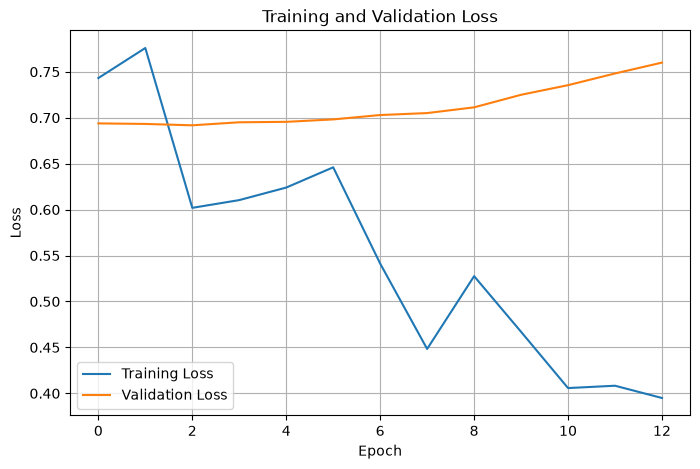

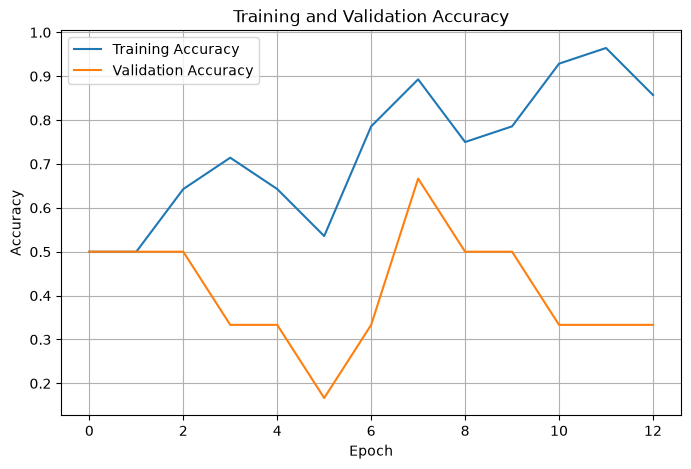


================ TEST RESULTS ================

Accuracy : 0.5
Precision: 0.0
Recall   : 0.0
F1-Score : 0.0

Confusion Matrix:
[[3 0]
 [3 0]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.50      1.00      0.67         3
    Positive       0.00      0.00      0.00         3

    accuracy                           0.50         6
   macro avg       0.25      0.50      0.33         6
weighted avg       0.25      0.50      0.33         6


================ UNSEEN SAMPLE PREDICTIONS ================

Text: The product is excellent and I am very happy
Prediction: Negative
Confidence: 51.73%
------------------------------------------------------------
Text: This service was terrible and disappointing
Prediction: Negative
Confidence: 52.97%
------------------------------------------------------------
Text: I really enjoyed the amazing experience
Prediction: Negative
Confidence: 50.91%
-------------------------------------------------------

In [1]:
# ============================================================
# TASK 05 - DEEP LEARNING / NLP TEXT CLASSIFIER
# Sentiment Analysis using PyTorch + TF-IDF
# ============================================================

import sys
import subprocess
import importlib.util

# ------------------------------------------------------------
# 1. Install PyTorch automatically if needed
# ------------------------------------------------------------

if importlib.util.find_spec("torch") is None:
    print("PyTorch not found. Installing PyTorch...")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "torch"
    ])

print("PyTorch is ready!")


# ------------------------------------------------------------
# 2. Imports
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


# ------------------------------------------------------------
# 3. Reproducibility
# ------------------------------------------------------------

np.random.seed(42)
torch.manual_seed(42)


# ------------------------------------------------------------
# 4. Self-contained Sentiment Dataset
# 0 = Negative
# 1 = Positive
# ------------------------------------------------------------

texts = [
    "The product quality is excellent",
    "I really loved this product",
    "The service was amazing",
    "Very happy with my purchase",
    "This product works perfectly",
    "The delivery was fast and reliable",
    "I am satisfied with the quality",
    "Excellent customer support",
    "The experience was wonderful",
    "I would definitely recommend this",
    "The product exceeded my expectations",
    "Very useful and easy to use",
    "Fantastic service from the company",
    "I am extremely happy",
    "The quality is impressive",
    "Great product and great service",
    "Everything worked perfectly",
    "I enjoyed using this product",
    "The purchase was worth it",
    "Very good experience",
    "The product is terrible",
    "I hated the experience",
    "The service was very poor",
    "I am unhappy with my purchase",
    "This product does not work",
    "The delivery was extremely slow",
    "The quality is disappointing",
    "Customer support was useless",
    "The experience was horrible",
    "I would not recommend this",
    "The product failed completely",
    "Very difficult to use",
    "Terrible service from the company",
    "I am extremely disappointed",
    "The quality is awful",
    "Bad product and bad service",
    "Nothing worked properly",
    "I regret buying this product",
    "Very poor experience",
    "The purchase was a waste of money"
]

labels = [
    1,1,1,1,1,1,1,1,1,1,
    1,1,1,1,1,1,1,1,1,1,
    0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0
]

df = pd.DataFrame({
    "text": texts,
    "sentiment": labels
})

print("Dataset created successfully!")
print("Total samples:", len(df))
print("\nClass distribution:")
print(df["sentiment"].value_counts())


# ------------------------------------------------------------
# 5. Train / Validation / Test Split
# ------------------------------------------------------------

X = df["text"]
y = df["sentiment"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\nSplit sizes:")
print("Training:", len(X_train))
print("Validation:", len(X_val))
print("Testing:", len(X_test))


# ------------------------------------------------------------
# 6. TF-IDF Vectorization
# Fit ONLY on training data
# ------------------------------------------------------------

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=500,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print("\nTF-IDF vectorization completed!")
print("Vocabulary size:", len(vectorizer.vocabulary_))


# ------------------------------------------------------------
# 7. Convert to PyTorch tensors
# ------------------------------------------------------------

X_train_tensor = torch.tensor(
    X_train_tfidf.toarray(),
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val_tfidf.toarray(),
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_tfidf.toarray(),
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
).reshape(-1, 1)

y_val_tensor = torch.tensor(
    y_val.values,
    dtype=torch.float32
).reshape(-1, 1)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.float32
).reshape(-1, 1)


# ------------------------------------------------------------
# 8. DataLoaders
# ------------------------------------------------------------

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False
)


# ------------------------------------------------------------
# 9. Deep Learning Neural Network
# Dropout + Batch Normalization
# ------------------------------------------------------------

class SentimentNetwork(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)


input_size = X_train_tensor.shape[1]

model = SentimentNetwork(input_size)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("\nNeural network created!")
print(model)


# ------------------------------------------------------------
# 10. Training with Early Stopping
# ------------------------------------------------------------

epochs = 100
patience = 10

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_loss = float("inf")
patience_counter = 0

best_model_state = None


for epoch in range(epochs):

    # -------------------------
    # Training
    # -------------------------

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_X, batch_y in train_loader:

        optimizer.zero_grad()

        outputs = model(batch_X)

        loss = criterion(outputs, batch_y)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        predictions = (
            torch.sigmoid(outputs) >= 0.5
        ).float()

        correct += (
            predictions == batch_y
        ).sum().item()

        total += batch_y.size(0)

    train_loss = running_loss / len(train_loader)

    train_accuracy = correct / total


    # -------------------------
    # Validation
    # -------------------------

    model.eval()

    val_loss_total = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for batch_X, batch_y in val_loader:

            outputs = model(batch_X)

            loss = criterion(outputs, batch_y)

            val_loss_total += loss.item()

            predictions = (
                torch.sigmoid(outputs) >= 0.5
            ).float()

            val_correct += (
                predictions == batch_y
            ).sum().item()

            val_total += batch_y.size(0)

    val_loss = val_loss_total / len(val_loader)

    val_accuracy = val_correct / val_total


    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    # -------------------------
    # Early Stopping
    # -------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_model_state = {
            key: value.clone()
            for key, value in model.state_dict().items()
        }

        patience_counter = 0

    else:

        patience_counter += 1


    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch {epoch+1:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Train Acc: {train_accuracy:.3f} | "
            f"Val Acc: {val_accuracy:.3f}"
        )


    if patience_counter >= patience:

        print(
            f"\nEarly stopping at epoch {epoch+1}"
        )

        break


# Restore best model
model.load_state_dict(best_model_state)

print("\nTraining completed!")


# ------------------------------------------------------------
# 11. Training Curves - Loss
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 12. Training Curves - Accuracy
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 13. Test Evaluation
# ------------------------------------------------------------

model.eval()

with torch.no_grad():

    test_logits = model(X_test_tensor)

    test_probabilities = torch.sigmoid(
        test_logits
    ).numpy().flatten()

test_predictions = (
    test_probabilities >= 0.5
).astype(int)

y_test_actual = y_test.values

accuracy = accuracy_score(
    y_test_actual,
    test_predictions
)

precision = precision_score(
    y_test_actual,
    test_predictions,
    zero_division=0
)

recall = recall_score(
    y_test_actual,
    test_predictions,
    zero_division=0
)

f1 = f1_score(
    y_test_actual,
    test_predictions,
    zero_division=0
)

print("\n================ TEST RESULTS ================\n")

print("Accuracy :", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall   :", round(recall, 3))
print("F1-Score :", round(f1, 3))

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_actual,
        test_predictions
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test_actual,
        test_predictions,
        target_names=["Negative", "Positive"],
        zero_division=0
    )
)


# ------------------------------------------------------------
# 14. Unseen Sample Predictions
# ------------------------------------------------------------

unseen_texts = [
    "The product is excellent and I am very happy",
    "This service was terrible and disappointing",
    "I really enjoyed the amazing experience",
    "The product quality is awful"
]

unseen_tfidf = vectorizer.transform(
    unseen_texts
)

unseen_tensor = torch.tensor(
    unseen_tfidf.toarray(),
    dtype=torch.float32
)

model.eval()

with torch.no_grad():

    unseen_logits = model(unseen_tensor)

    unseen_probabilities = torch.sigmoid(
        unseen_logits
    ).numpy().flatten()


print("\n================ UNSEEN SAMPLE PREDICTIONS ================\n")

for text, probability in zip(
    unseen_texts,
    unseen_probabilities
):

    prediction = (
        "Positive"
        if probability >= 0.5
        else "Negative"
    )

    confidence = (
        probability
        if probability >= 0.5
        else 1 - probability
    )

    print("Text:", text)
    print("Prediction:", prediction)
    print("Confidence:", f"{confidence:.2%}")
    print("-" * 60)


# ------------------------------------------------------------
# 15. Save Model + Vectorizer
# ------------------------------------------------------------

torch.save(
    model.state_dict(),
    "task05_sentiment_model.pth"
)

import joblib

joblib.dump(
    vectorizer,
    "task05_tfidf_vectorizer.joblib"
)

print("\n================ TASK 05 COMPLETE ================\n")

print("✓ Text dataset created")
print("✓ TF-IDF vectorization completed")
print("✓ PyTorch neural network built")
print("✓ Batch Normalization used")
print("✓ Dropout used")
print("✓ Early stopping implemented")
print("✓ Training/validation curves generated")
print("✓ Test evaluation completed")
print("✓ Unseen text predictions generated")
print("✓ Model saved")
print("✓ TF-IDF vectorizer saved")